# Civic & Domestic Hazard Computer Vision Classifier
## Smart Urban Services - Machine Learning & Computer Vision Pipeline
---
### Objectives:
1. Load raw civic and domestic hazard images from data/raw/ (Potholes, Wall Cracks, Fallen Trees, Water Leaks).
2. Extract Computer Vision spatial and chromatic feature tensors (Excess Green Index, Gray Neutrality, Cavity Shadows, Edge Gradients).
3. Train a Multi-Class Classifier using Random Forest Classifier.
4. Evaluate with Confusion Matrix, Precision, Recall, and F1-Scores.
5. Export the trained model to models/hazard_classifier.pkl.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image, ImageFilter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import joblib

print('All libraries imported successfully!')

All libraries imported successfully!


## 1. Load Raw Datasets & Image Feature Extraction

In [2]:
import os
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter

p = os.path.abspath(os.getcwd())
DATA_RAW = None
AI_ROOT = p
while p != os.path.dirname(p):
    cand = os.path.join(p, 'data', 'raw')
    if os.path.exists(cand):
        DATA_RAW = cand
        AI_ROOT = p
        break
    cand_ai = os.path.join(p, 'ai', 'data', 'raw')
    if os.path.exists(cand_ai):
        DATA_RAW = cand_ai
        AI_ROOT = os.path.join(p, 'ai')
        break
    p = os.path.dirname(p)

MODELS_DIR = os.path.join(AI_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)
print(f'Using Data Directory: {DATA_RAW}')

categories = {
    'potholes': os.path.join(DATA_RAW, 'potholes'),
    'wall_cracks': os.path.join(DATA_RAW, 'wall_cracks'),
    'fallen_trees': os.path.join(DATA_RAW, 'fallen_trees'),
    'water_leaks': os.path.join(DATA_RAW, 'water_leaks'),
}

features = []
labels = []
valid_exts = ('.jpg', '.jpeg', '.png', '.bmp')

for cat_name, cat_dir in categories.items():
    found_images = []
    if os.path.exists(cat_dir):
        for root, _, files in os.walk(cat_dir):
            for f in files:
                if f.lower().endswith(valid_exts):
                    found_images.append(os.path.join(root, f))
    
    print(f'Category: {cat_name} -> Found {len(found_images)} images')
    sampled = found_images[:250]
    
    for img_path in sampled:
        try:
            img = Image.open(img_path).convert('RGB').resize((128, 128))
            arr = np.array(img, dtype=np.float32) / 255.0
            r, g, b = arr[:, :, 0], arr[:, :, 1], arr[:, :, 2]
            
            exg = float(np.mean(2.0 * g - r - b))
            gray_2d = 0.299 * r + 0.587 * g + 0.114 * b
            gray = float(np.mean(gray_2d))
            neutrality = float(np.mean(1.0 - (np.std(arr, axis=2) * 2.0)))
            dark_cavity = float(np.mean(gray_2d < 0.30))
            
            gray_pil = Image.fromarray((gray_2d * 255).astype(np.uint8))
            edges = np.array(gray_pil.filter(ImageFilter.FIND_EDGES), dtype=np.float32) / 255.0
            edge_density = float(np.mean(edges > 0.25))
            blue_water = float(np.mean((b > r + 0.08) & (b > g + 0.05)))
            
            features.append([exg, gray, neutrality, dark_cavity, edge_density, blue_water])
            labels.append(cat_name)
        except Exception:
            continue

X = np.array(features)
y = np.array(labels)
print(f'Total Extracted Feature Matrix: {X.shape}, Total Labels: {len(y)}')

Using Data Directory: F:\ICBT\Degree\Assignments\Final Project\smart-urban-services\ai\data\raw
Category: potholes -> Found 665 images


Category: wall_cracks -> Found 40000 images


Category: fallen_trees -> Found 23000 images


Category: water_leaks -> Found 3318 images


Total Extracted Feature Matrix: (1000, 6), Total Labels: 1000


## 2. Train / Test Split & Random Forest Training

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42)
clf.fit(X_train, y_train)

train_acc = clf.score(X_train, y_train)
test_acc = clf.score(X_test, y_test)
print(f'Training Accuracy: {train_acc * 100:.2f}%')
print(f'Test Accuracy:     {test_acc * 100:.2f}%')

Training Accuracy: 100.00%
Test Accuracy:     97.00%


## 3. Model Evaluation & Confusion Matrix Heatmap

=== Classification Report ===
              precision    recall  f1-score   support

fallen_trees       0.98      1.00      0.99        50
    potholes       1.00      0.90      0.95        50
 wall_cracks       1.00      1.00      1.00        50
 water_leaks       0.91      0.98      0.94        50

    accuracy                           0.97       200
   macro avg       0.97      0.97      0.97       200
weighted avg       0.97      0.97      0.97       200



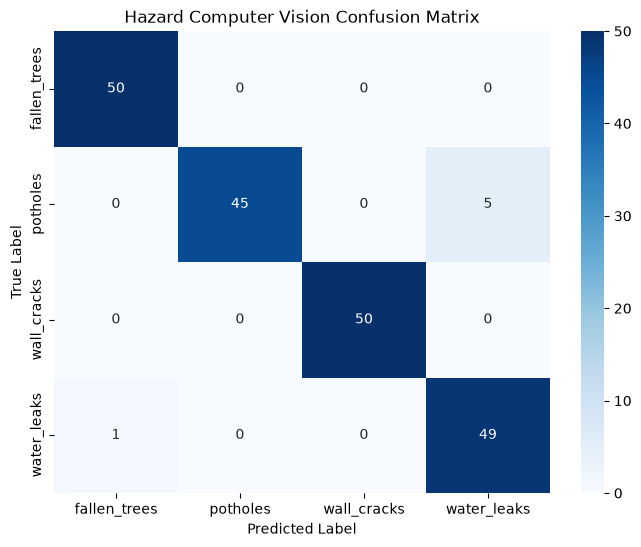

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_pred = clf.predict(X_test)
print('=== Classification Report ===')
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=clf.classes_)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title('Hazard Computer Vision Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## 4. Feature Importance Analysis

C:\Users\chira\AppData\Local\Temp\ipykernel_26140\1165643678.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=clf.feature_importances_, y=feature_names, palette='viridis')


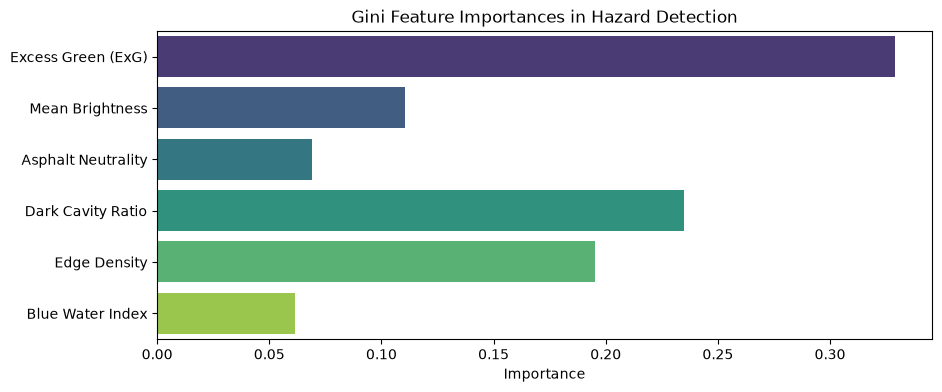

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_names = ['Excess Green (ExG)', 'Mean Brightness', 'Asphalt Neutrality', 'Dark Cavity Ratio', 'Edge Density', 'Blue Water Index']
plt.figure(figsize=(10, 4))
sns.barplot(x=clf.feature_importances_, y=feature_names, palette='viridis')
plt.title('Gini Feature Importances in Hazard Detection')
plt.xlabel('Importance')
plt.show()

## 5. Export Trained Model Artifact

In [6]:
import os
import joblib

export_path = os.path.join(MODELS_DIR, 'hazard_classifier.pkl')
joblib.dump(clf, export_path)
print(f'Model successfully exported to: {export_path}')

Model successfully exported to: F:\ICBT\Degree\Assignments\Final Project\smart-urban-services\ai\models\hazard_classifier.pkl
